# Notebook de travail

Projet : Smart City Energy Forecasting — Tetouan


Importation des bibliothèques et configuration visuelle

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pathlib import Path

# Configuration esthétique pour un rendu professionnel
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.figsize': (14, 6), 'axes.titlesize': 14})

# Création du dossier pour sauvegarder les figures
Path("../results/figures").mkdir(parents=True, exist_ok=True)

Chargement des données et rééchantillonnage horaire

In [4]:
df = pd.read_csv("../data/raw/Tetuan City power consumption.csv")
df = df.rename(columns={
    "DateTime": "datetime", "Temperature": "temperature", "Humidity": "humidity",
    "Wind Speed": "wind_speed", "general diffuse flows": "general_diffuse_flows",
    "diffuse flows": "diffuse_flows", "Zone 1 Power Consumption": "zone1_power",
    "Zone 2 Power Consumption": "zone2_power", "Zone 3 Power Consumption": "zone3_power"
})
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.set_index("datetime").sort_index()

# Création de la cible
df["target"] = df["zone1_power"]

# Rééchantillonnage horaire par moyenne pour lisser le signal
df_hourly = df.resample("1h").mean()

print(f"Dimensions après rééchantillonnage horaire : {df_hourly.shape}")

Dimensions après rééchantillonnage horaire : (8736, 9)


Dynamique temporelle et distribution

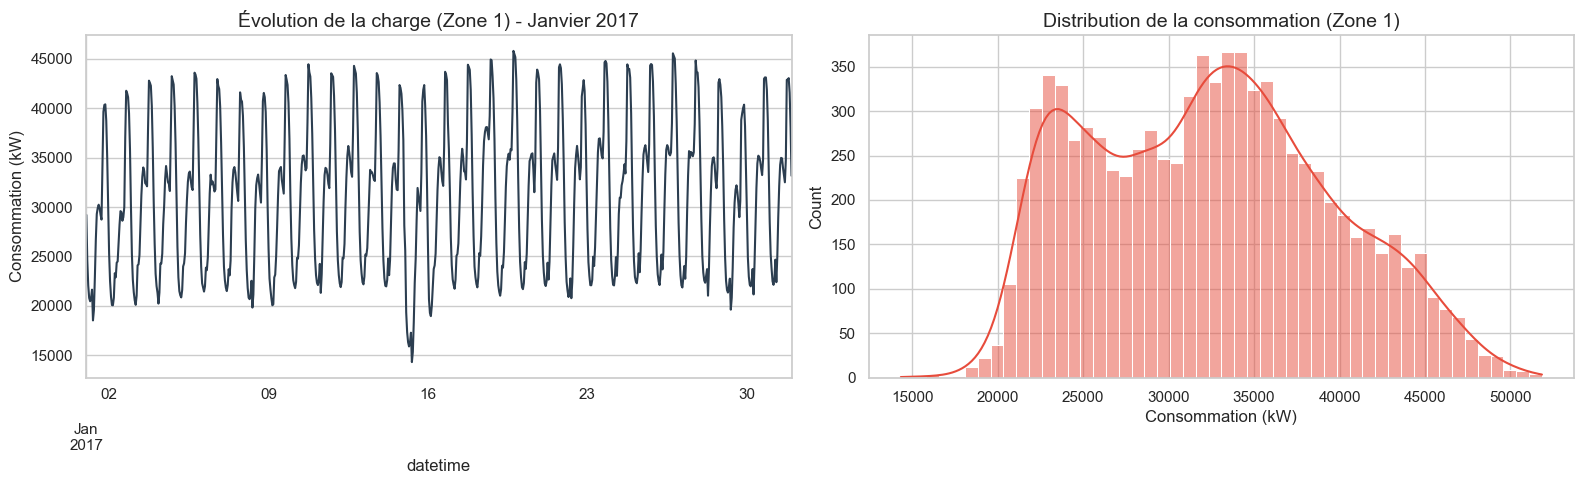

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Graphique 1 : Évolution temporelle sur un mois (Janvier 2017)
df_hourly['target'].loc['2017-01-01':'2017-01-31'].plot(ax=axes[0], color='#2c3e50')
axes[0].set_title("Évolution de la charge (Zone 1) - Janvier 2017")
axes[0].set_ylabel("Consommation (kW)")

# Graphique 2 : Distribution globale
sns.histplot(df_hourly['target'], bins=50, kde=True, ax=axes[1], color='#e74c3c')
axes[1].set_title("Distribution de la consommation (Zone 1)")
axes[1].set_xlabel("Consommation (kW)")

plt.tight_layout()
plt.savefig("../results/figures/dynamique_et_distribution.png")
plt.show()

Profils d'activité humaine (Extraction de la temporalité)

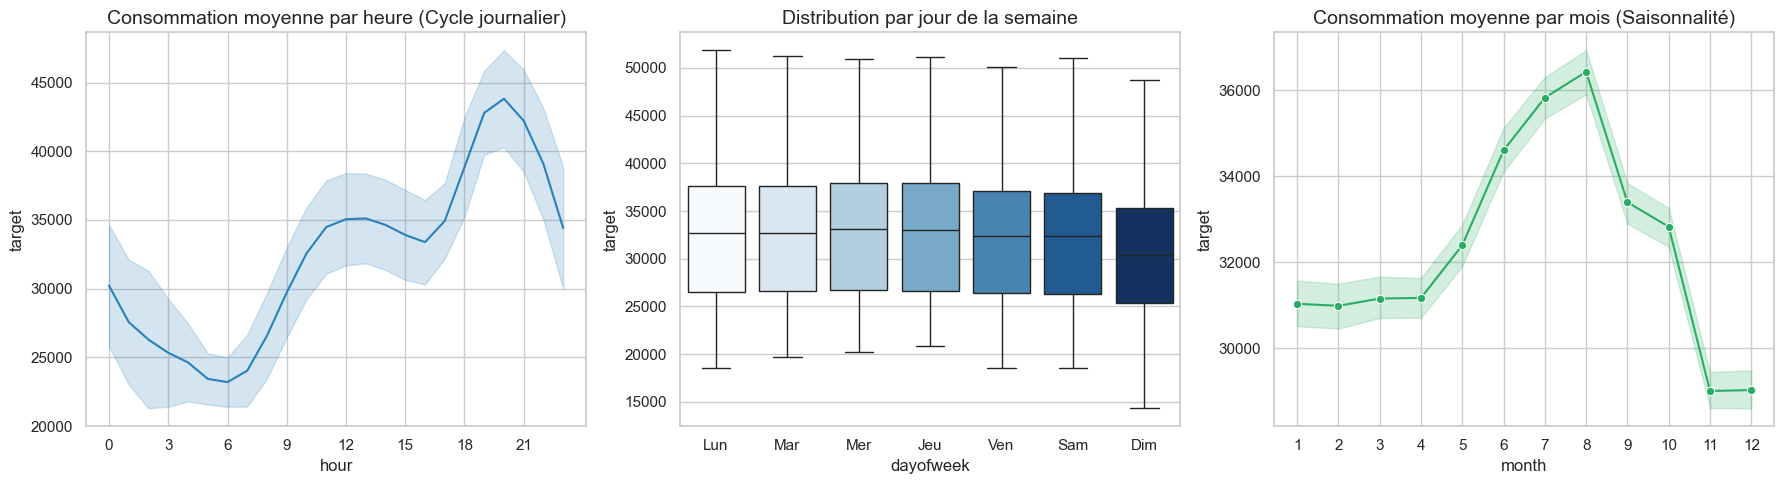

In [13]:
df_hourly['hour'] = df_hourly.index.hour
df_hourly['dayofweek'] = df_hourly.index.dayofweek
df_hourly['month'] = df_hourly.index.month

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Consommation moyenne par heure
sns.lineplot(data=df_hourly, x='hour', y='target', ax=axes[0], errorbar='sd', color='#2980b9')
axes[0].set_title("Consommation moyenne par heure (Cycle journalier)")
axes[0].set_xticks(range(0, 24, 3))

# Consommation moyenne par jour de la semaine (0=Lundi, 6=Dimanche)
sns.boxplot(data=df_hourly, x='dayofweek', y='target', ax=axes[1], hue='dayofweek', palette="Blues", legend=False)
axes[1].set_title("Distribution par jour de la semaine")

axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim'])

# Consommation moyenne par mois
sns.lineplot(data=df_hourly, x='month', y='target', ax=axes[2], color='#27ae60', marker='o')
axes[2].set_title("Consommation moyenne par mois (Saisonnalité)")
axes[2].set_xticks(range(1, 13))

plt.tight_layout()
plt.savefig("../results/figures/profils_temporels.png")
plt.show()

Heatmap d'activité (Heure vs Jour de la semaine)

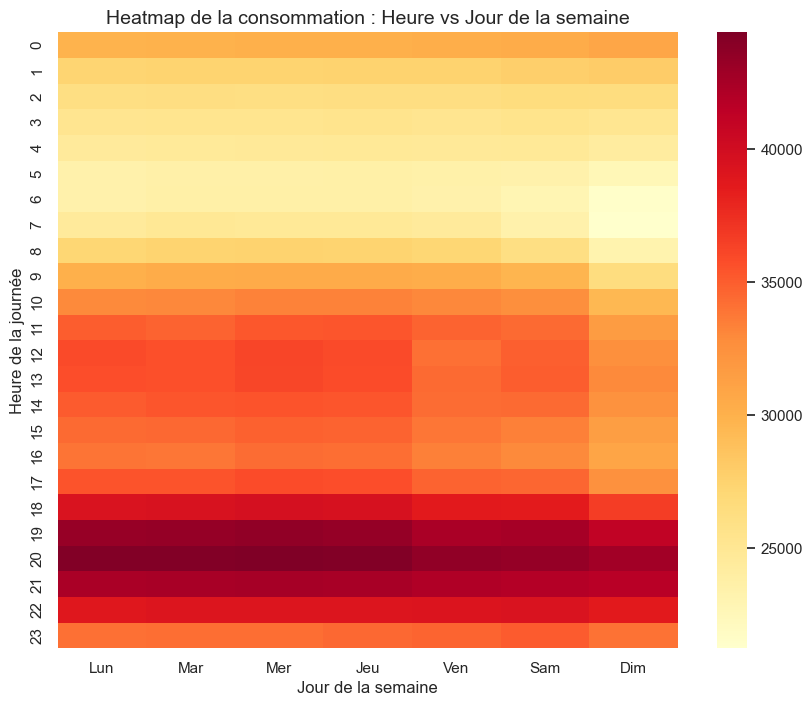

In [14]:
pivot_table = df_hourly.pivot_table(values='target', index='hour', columns='dayofweek', aggfunc='mean')
pivot_table.columns = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, cmap="YlOrRd", annot=False, fmt=".0f")
plt.title("Heatmap de la consommation : Heure vs Jour de la semaine")
plt.ylabel("Heure de la journée")
plt.xlabel("Jour de la semaine")
plt.savefig("../results/figures/heatmap_heure_jour.png")
plt.show()

Analyse Météorologique et Matrice de Corrélation

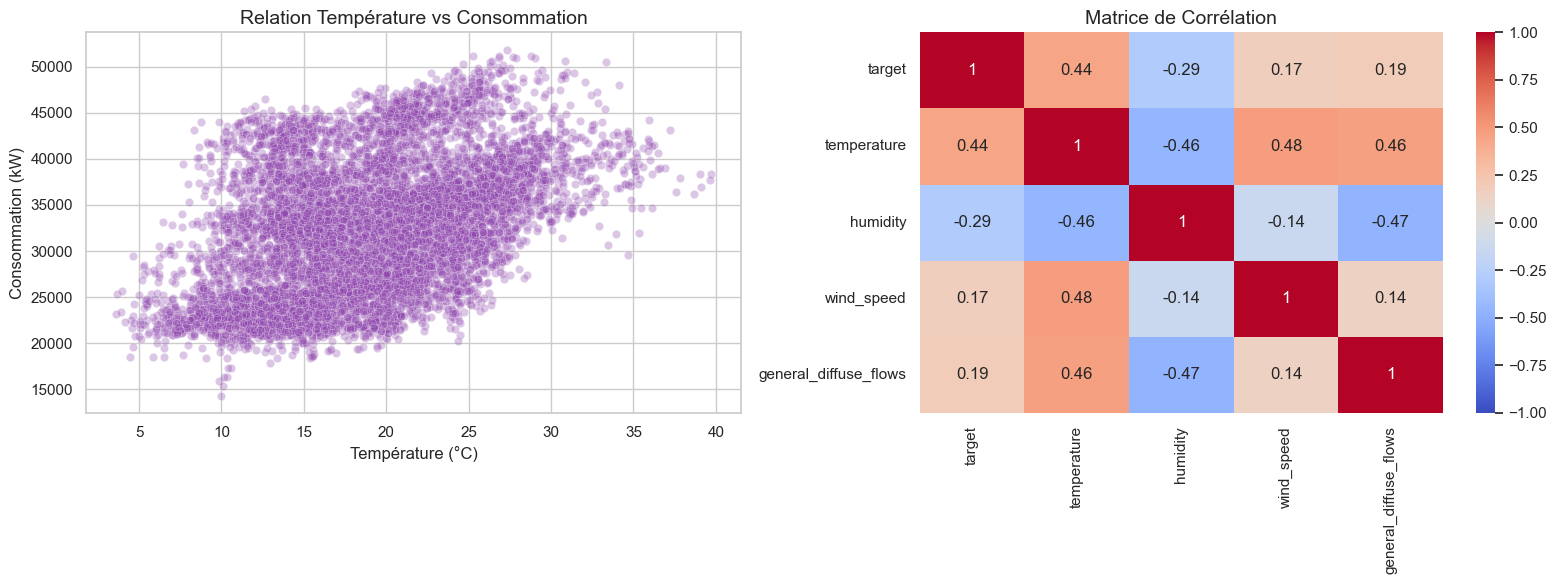

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Relation non-linéaire Température vs Consommation
sns.scatterplot(data=df_hourly, x='temperature', y='target', alpha=0.3, ax=axes[0], color='#8e44ad')
axes[0].set_title("Relation Température vs Consommation")
axes[0].set_xlabel("Température (°C)")
axes[0].set_ylabel("Consommation (kW)")
# Matrice de corrélation de Pearson
cols_to_corr = ['target', 'temperature', 'humidity', 'wind_speed', 'general_diffuse_flows']
corr_matrix = df_hourly[cols_to_corr].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Matrice de Corrélation")

plt.tight_layout()
plt.savefig("../results/figures/meteo_correlation.png")
plt.show()

Mémoire de la série (ACF et PACF) pour les modèles Auto-régressifs

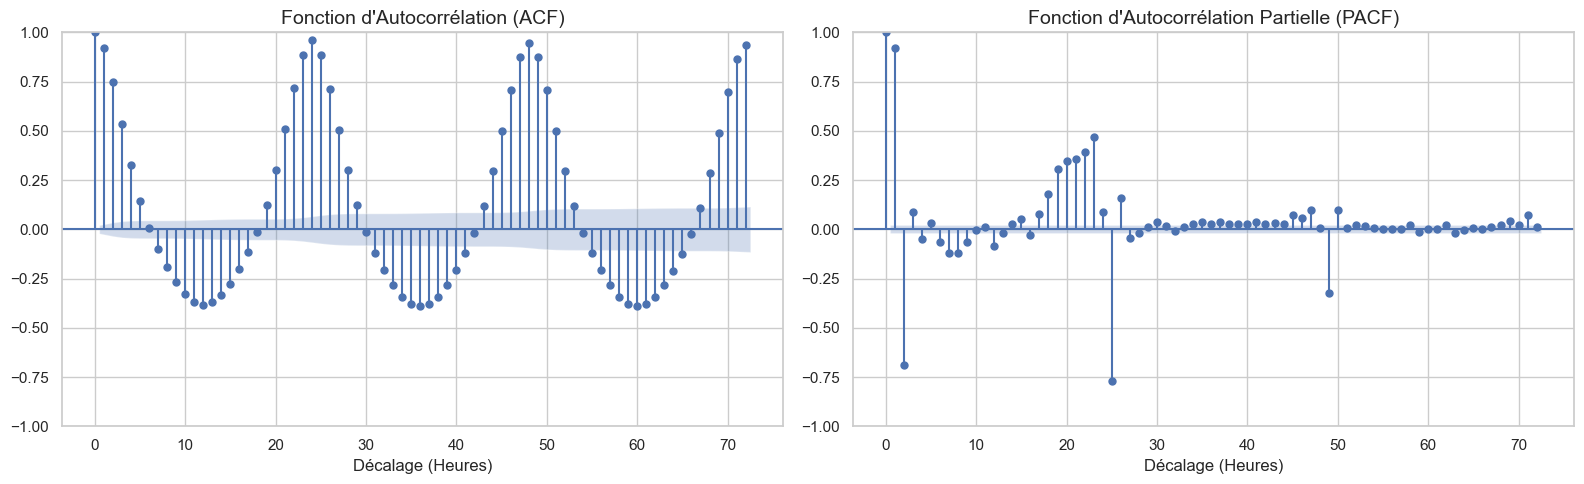

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Autocorrélation (ACF) - Lags jusqu'à 72 heures (3 jours)
plot_acf(df_hourly['target'].dropna(), lags=72, ax=axes[0], alpha=0.05)
axes[0].set_title("Fonction d'Autocorrélation (ACF)")
axes[0].set_xlabel("Décalage (Heures)")

# Autocorrélation Partielle (PACF)
plot_pacf(df_hourly['target'].dropna(), lags=72, ax=axes[1], alpha=0.05)
axes[1].set_title("Fonction d'Autocorrélation Partielle (PACF)")
axes[1].set_xlabel("Décalage (Heures)")

plt.tight_layout()
plt.savefig("../results/figures/acf_pacf.png")
plt.show()